#  Fraudulent Transactions Data Analysis
##  Exploratory Data Analysis (EDA) & Data Preparation

###  Methodology: CRISP-DM Framework
This project is structured based on the **Cross-Industry Standard Process for Data Mining (CRISP-DM)** framework to ensure a comprehensive and business-aligned approach to fraud detection. 

This specific notebook covers the first three phases of the methodology:

1. **Define the business problem.**
2. **Collect the data and get a general overview of it.**
3. **Split the data into train and test sets.**
4. **Explore the data (exploratory data analysis).**
5. **Data cleaning and preprocessing.**
6. **Model training, comparison, selection and tuning.**
7. **Final production model testing and evaluation.**
8. **Conclude and interpret the model results.**
9. **Deploy.**


# **1. DEFINE THE BUSINESS PROBLEM.**
Financial fraud is a growing challenge for financial institutions, leading to direct monetary losses, increased operational costs, and damage to customer trust. In mobile money environments, malicious agents often attempt to compromise accounts, transfer funds, and cash out before being detected.

Project Goal: The primary objective of this project is to develop a robust, data-driven risk analysis pipeline. By identifying hidden patterns in transactional data, we aim to build a predictive model that accurately flags fraudulent activities (CASH-OUT and TRANSFER operations) in real-time.

Business Value: A successful model will minimize financial exposure and optimize the fraud detection process, focusing on a high detection rate while strictly controlling false positives to ensure legitimate users are not negatively impacted.

### 1.1. Importing the libraries

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import polars as pl
import plotly.express as px
import plotly.io as pio

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE

import fraud_detection.visualizer as vis
import fraud_detection.statistical_test as tests

pio.renderers.default = "png"
px.colors.qualitative.G10



RANDOM_STATE = 42

# **2. UNDERSTANDING THE DATA.**

* The dataset was collected from Kaggle: https://www.kaggle.com/datasets/chitwanmanchanda/fraudulent-transactions-data/data

* This dataset is derived from the renowned **PaySim** synthetic dataset. PaySim is a financial mobile money simulator designed to generate synthetic data that closely resembles the normal operation of transactions, while mathematically injecting malicious behavior to evaluate fraud detection methods.
The underlying simulation is based on a sample of real transactions extracted from one month of financial logs from a mobile money service implemented in an African country.

 **Original Academic Citation:**
*E. A. Lopez-Rojas, A. Elmir, and S. Axelsson. "PaySim: A financial mobile money simulator for fraud detection". In: The 28th European Modeling and Simulation Symposium-EMSS, Larnaca, Cyprus. 2016.*

In [2]:
data_path = '/data/PROJETOS/ALURA-FRAUDE/data/Fraud.csv'
df = pl.read_csv(data_path)

In [3]:
df.head()

step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
i64,str,f64,str,f64,f64,str,f64,f64,i64,i64
1,"""PAYMENT""",9839.64,"""C1231006815""",170136.0,160296.36,"""M1979787155""",0.0,0.0,0,0
1,"""PAYMENT""",1864.28,"""C1666544295""",21249.0,19384.72,"""M2044282225""",0.0,0.0,0,0
1,"""TRANSFER""",181.0,"""C1305486145""",181.0,0.0,"""C553264065""",0.0,0.0,1,0
1,"""CASH_OUT""",181.0,"""C840083671""",181.0,0.0,"""C38997010""",21182.0,0.0,1,0
1,"""PAYMENT""",11668.14,"""C2048537720""",41554.0,29885.86,"""M1230701703""",0.0,0.0,0,0


### 2.1 **Data Dictionary**

1. **step** - maps a unit of time in the real world. In this case 1 step is 1 hour of time. Total steps 744 (30 days simulation).

2. **type** - CASH-IN, CASH-OUT, DEBIT, PAYMENT and TRANSFER.

3. **amount** - amount of the transaction in local currency.

4. **nameOrig** - customer who started the transaction

5. **oldbalanceOrg** - initial balance before the transaction

6. **newbalanceOrig** - new balance after the transaction

7. **nameDest** - customer who is the recipient of the transaction

8. **oldbalanceDest** - initial balance recipient before the transaction. Note that there is not information for customers that start with M (Merchants).

9. **newbalanceDest** - new balance recipient after the transaction. Note that there is not information for customers that start with M (Merchants).

10. **isFraud** - This is the transactions made by the fraudulent agents inside the simulation. In this specific dataset the fraudulent behavior of the agents aims to profit by taking control or customers accounts and try to empty the funds by transferring to another account and then cashing out of the system.

11. **isFlaggedFraud** - The business model aims to control massive transfers from one account to another and flags illegal attempts. An illegal attempt in this dataset is an attempt to transfer more than 200.000 in a single transaction.

In [4]:
df.describe()

statistic,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
str,f64,str,f64,str,f64,f64,str,f64,f64,f64,f64
"""count""",6.36262e6,"""6362620""",6.36262e6,"""6362620""",6.36262e6,6.36262e6,"""6362620""",6.36262e6,6.36262e6,6.36262e6,6.36262e6
"""null_count""",0.0,"""0""",0.0,"""0""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0
"""mean""",243.397246,null,179861.903549,null,833883.104074,855113.668579,null,1.1007e6,1.2250e6,0.001291,0.000003
"""std""",142.331971,null,603858.231463,null,2.8882e6,2.9240e6,null,3.3992e6,3.6741e6,0.035905,0.001586
"""min""",1.0,"""CASH_IN""",0.0,"""C1000000639""",0.0,0.0,"""C1000004082""",0.0,0.0,0.0,0.0
"""25%""",156.0,null,13389.57,null,0.0,0.0,null,0.0,0.0,0.0,0.0
"""50%""",239.0,null,74872.08,null,14208.0,0.0,null,132705.81,214661.65,0.0,0.0
"""75%""",335.0,null,208721.45,null,107315.0,144258.41,null,943036.53,1.1119e6,0.0,0.0
"""max""",743.0,"""TRANSFER""",9.2446e7,"""C999999784""",5.9585e7,4.9585e7,"""M999999784""",3.5602e8,3.5618e8,1.0,1.0


#### **Insights**


* **Flawless Data Quality (No Nulls):** The null_count row shows 0.0 for absolutely all columns. There will be no need to apply missing data imputation techniques to this original dataset.

* **Extreme Target Variable Imbalance:** The mean of the isFraud column is only 0.001291. This indicates that **only ~0.13% of the transactions** in the dataset represent confirmed frauds. Future Machine Learning models will require balancing techniques.

* **Inefficiency of the Current Business Rule (isFlaggedFraud):** The current system's flagging mean (0.000003) is significantly lower than the actual frauds, indicating that the fixed rule (transfers > 200,000) fails to capture malicious behavior. This provides strong technical and commercial justification for building a robust predictive model.

* **Asymmetry and Outliers in Transaction Values (amount):** The transaction amount column is highly right-skewed. While the 3rd quartile (75%) concentrates transactions up to ~208k, the maximum value reaches over **92 million**. The mean (~179k) is considerably pulled up by these extreme values compared to the median (~74k).


# **3. SPLIT THE DATA INTO TRAIN AND TEST**

In [5]:
df = df.with_columns([
    (pl.col('oldbalanceOrg') - pl.col('amount') - pl.col('newbalanceOrig')).alias('errorBalanceOrig'),
    (pl.col('oldbalanceDest') + pl.col('amount') - pl.col('newbalanceDest')).alias('errorBalanceDest'),
    pl.col('nameDest').str.starts_with('M').cast(pl.Int8).alias('is_merchant_dest')   
]).drop(['nameOrig', 'isFlaggedFraud', 'nameDest'])

In [6]:
X = df.drop('isFraud')
y = df.select('isFraud')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y 
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['type'])
    ],
    remainder='passthrough'
).set_output(transform="polars") 


pipeline_preprocessing = Pipeline(
    steps=[
        ('preprocessor', preprocessor)
    ]
)


X_train_transformed = pipeline_preprocessing.fit_transform(X_train)
X_test_transformed = pipeline_preprocessing.transform(X_test)


Train: 5090096 rows | Test: 1272524 rows


# **4. DATA ANALYSIS**

In [7]:
fraud_palette = {0: '#2ecc71', 1: '#e74c3c'}

### Target distribution

<Axes: title={'center': 'RELATIVE FREQUENCY: ISFRAUD'}, xlabel='isFraud', ylabel='Percentage (%)'>

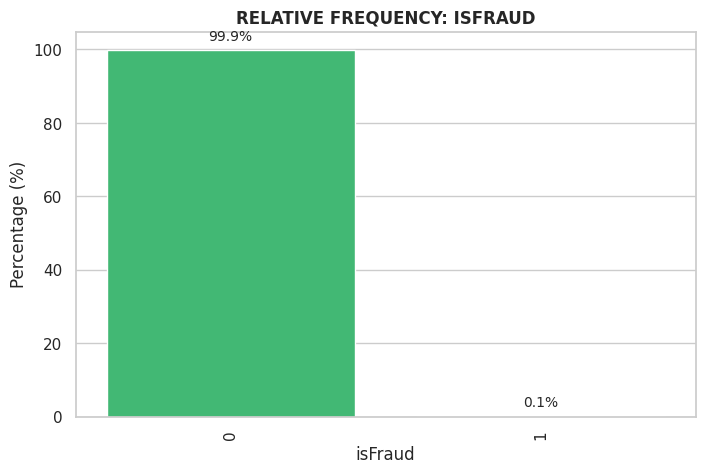

In [8]:
vis.plot_relative_frequency(
    df= df.to_pandas(),
    feature= 'isFraud',
    color_map=fraud_palette
)

##### The target is imbalanced. 0.1% of the registers are frauds.  

### Numerical features distributions

In [9]:
numplot_features = [
    'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig',
    'errorBalanceDest'
]

catplot_features = [
    'type'
]


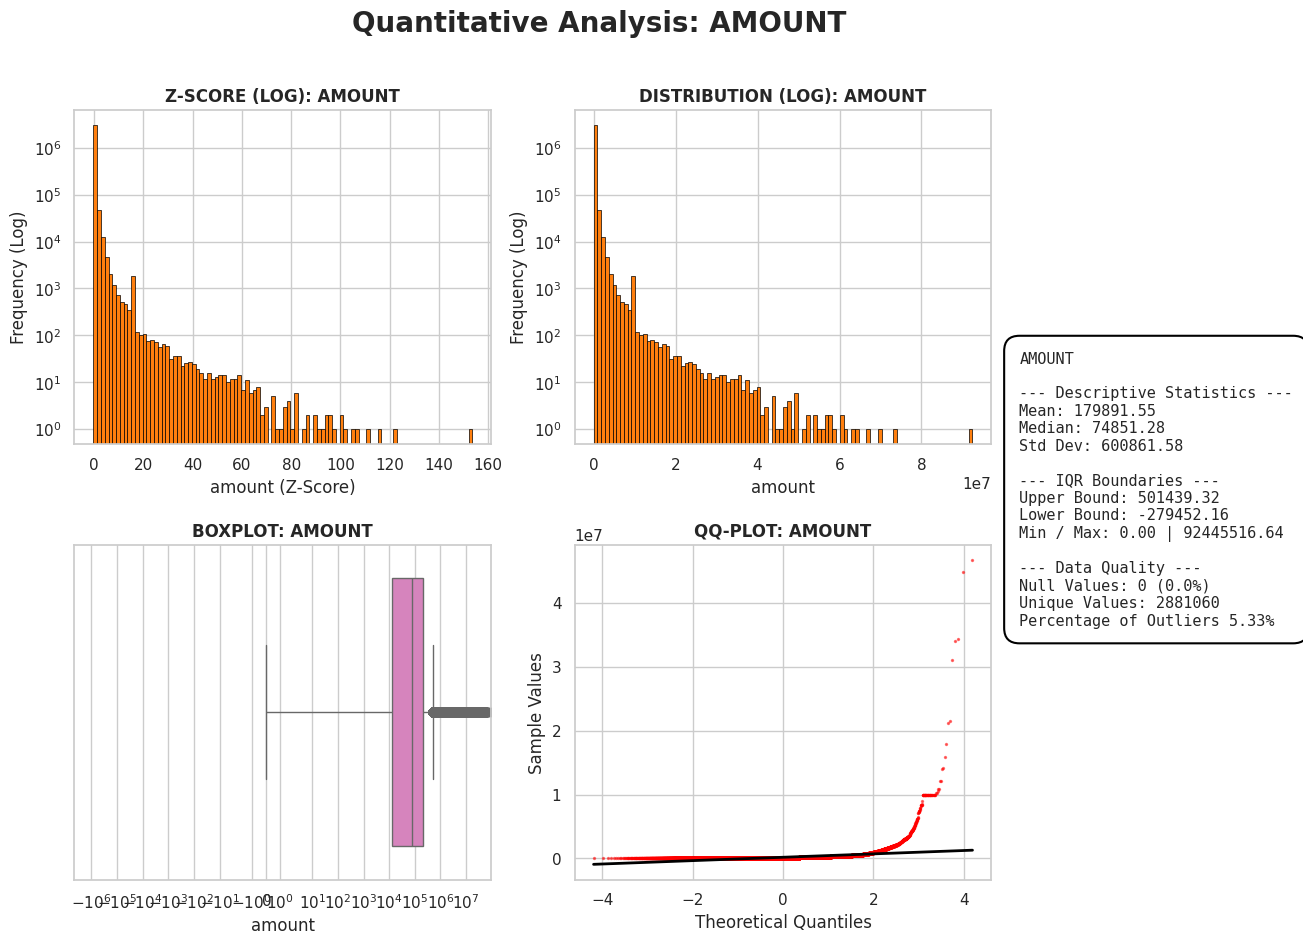

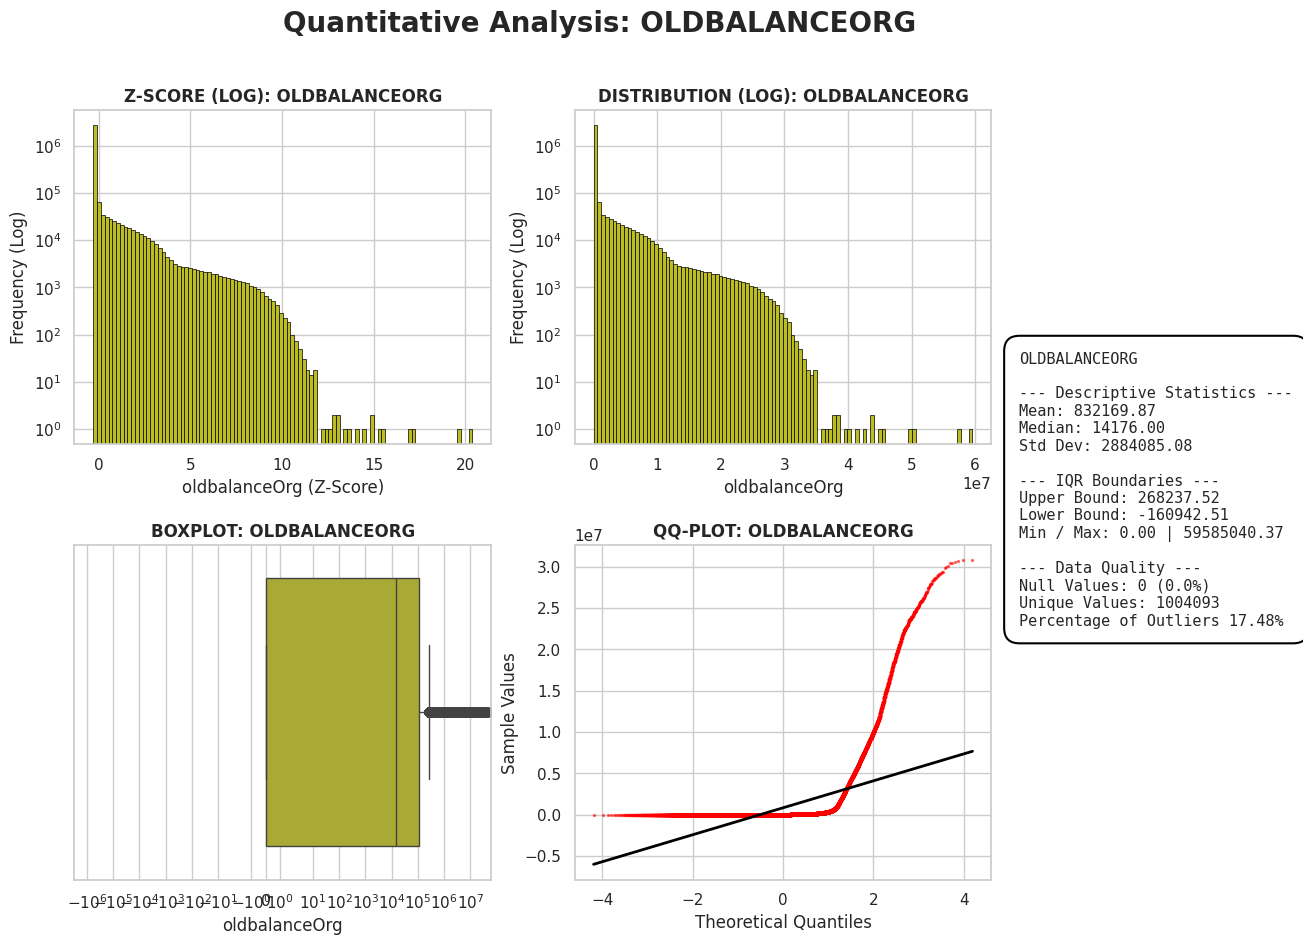

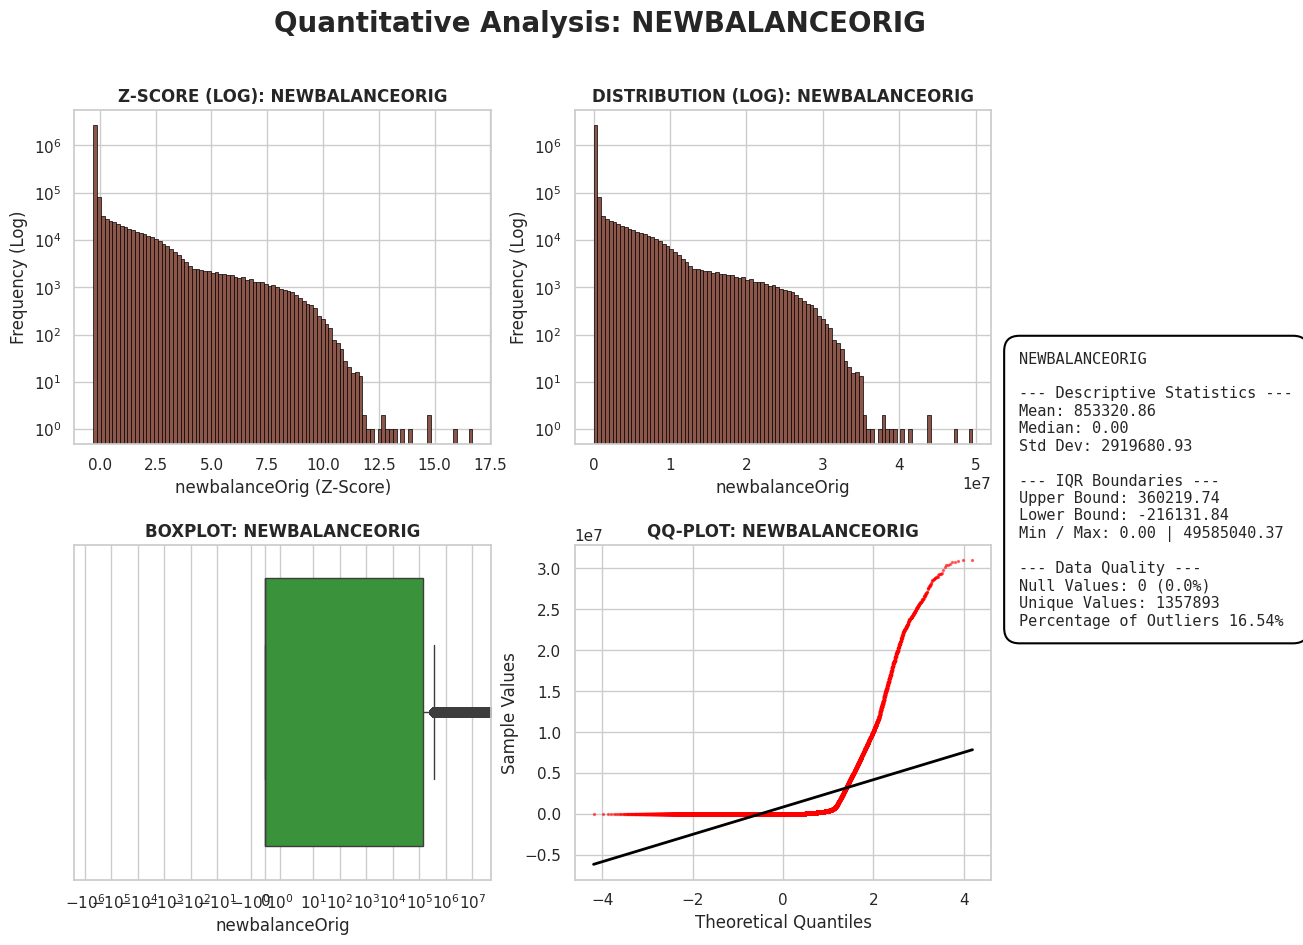

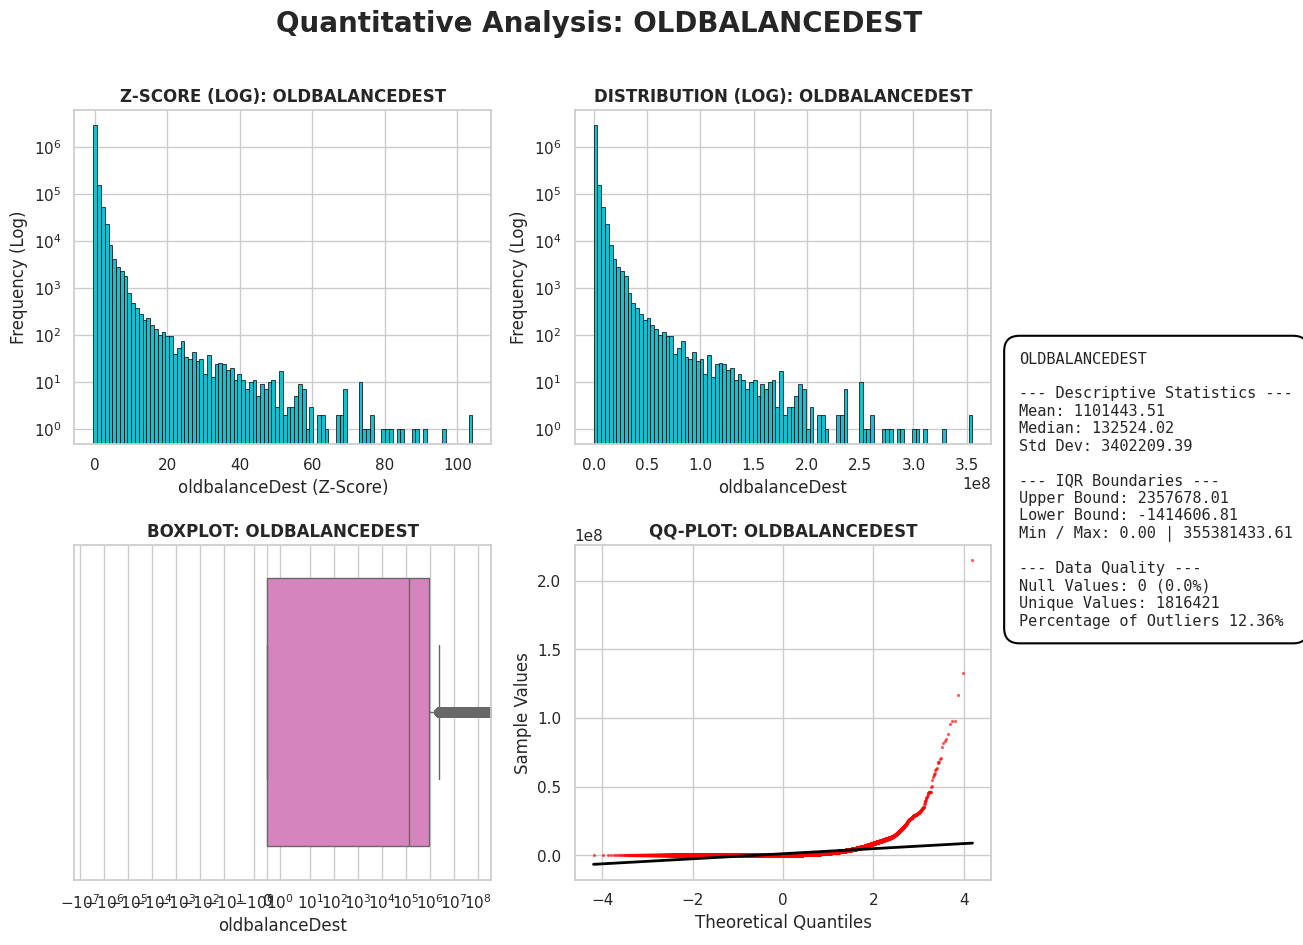

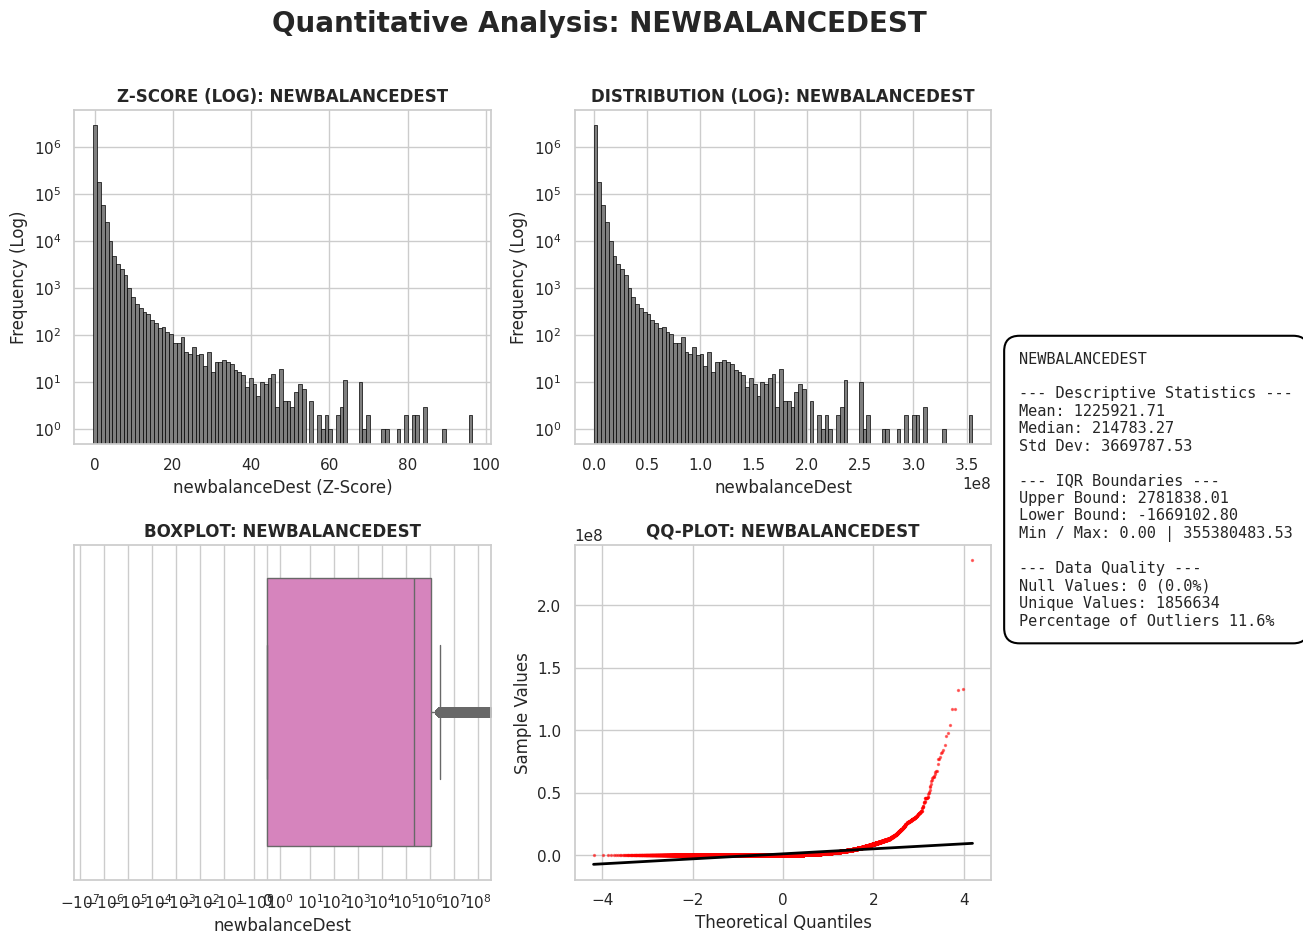

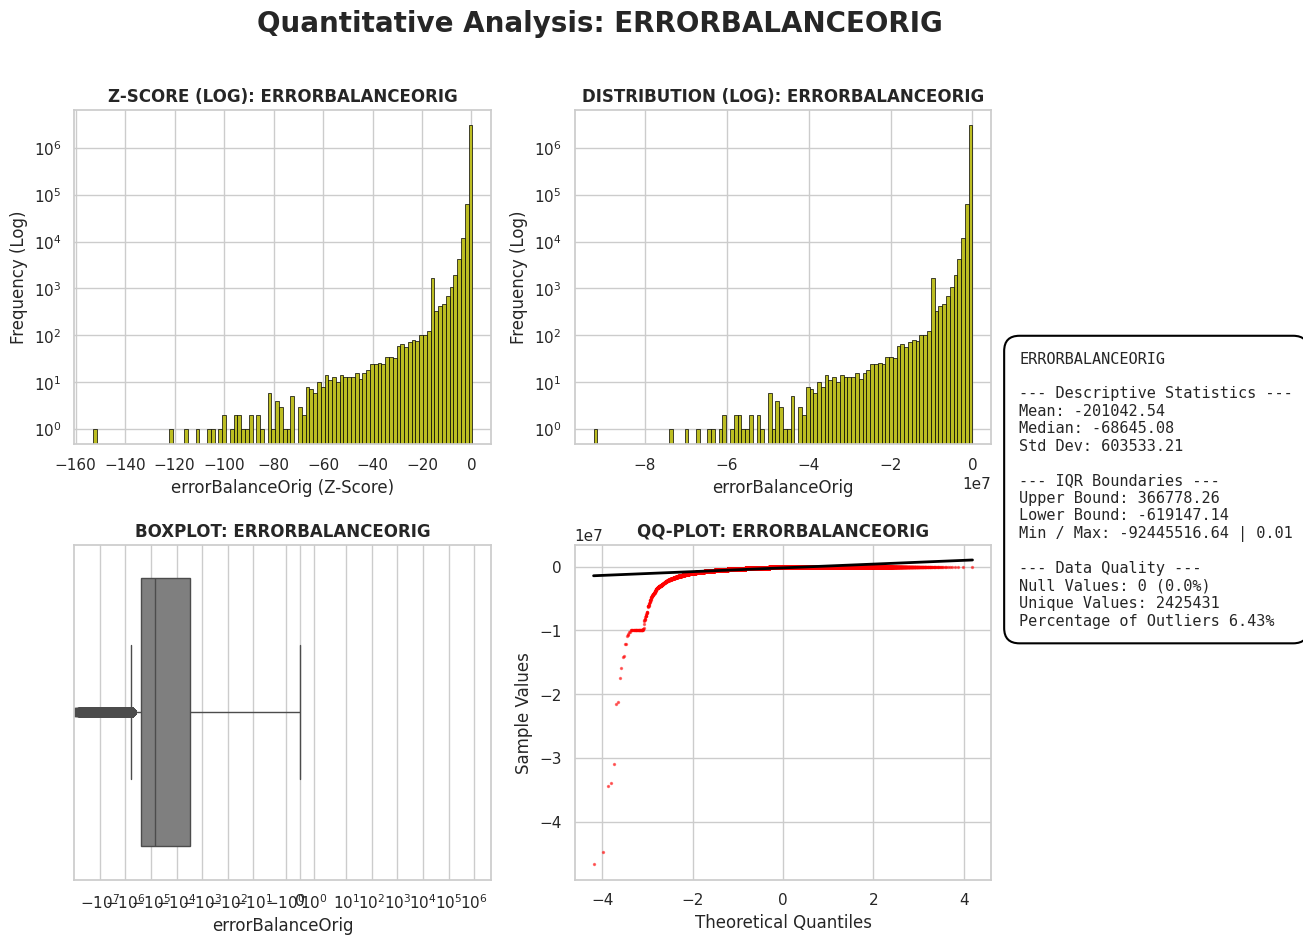

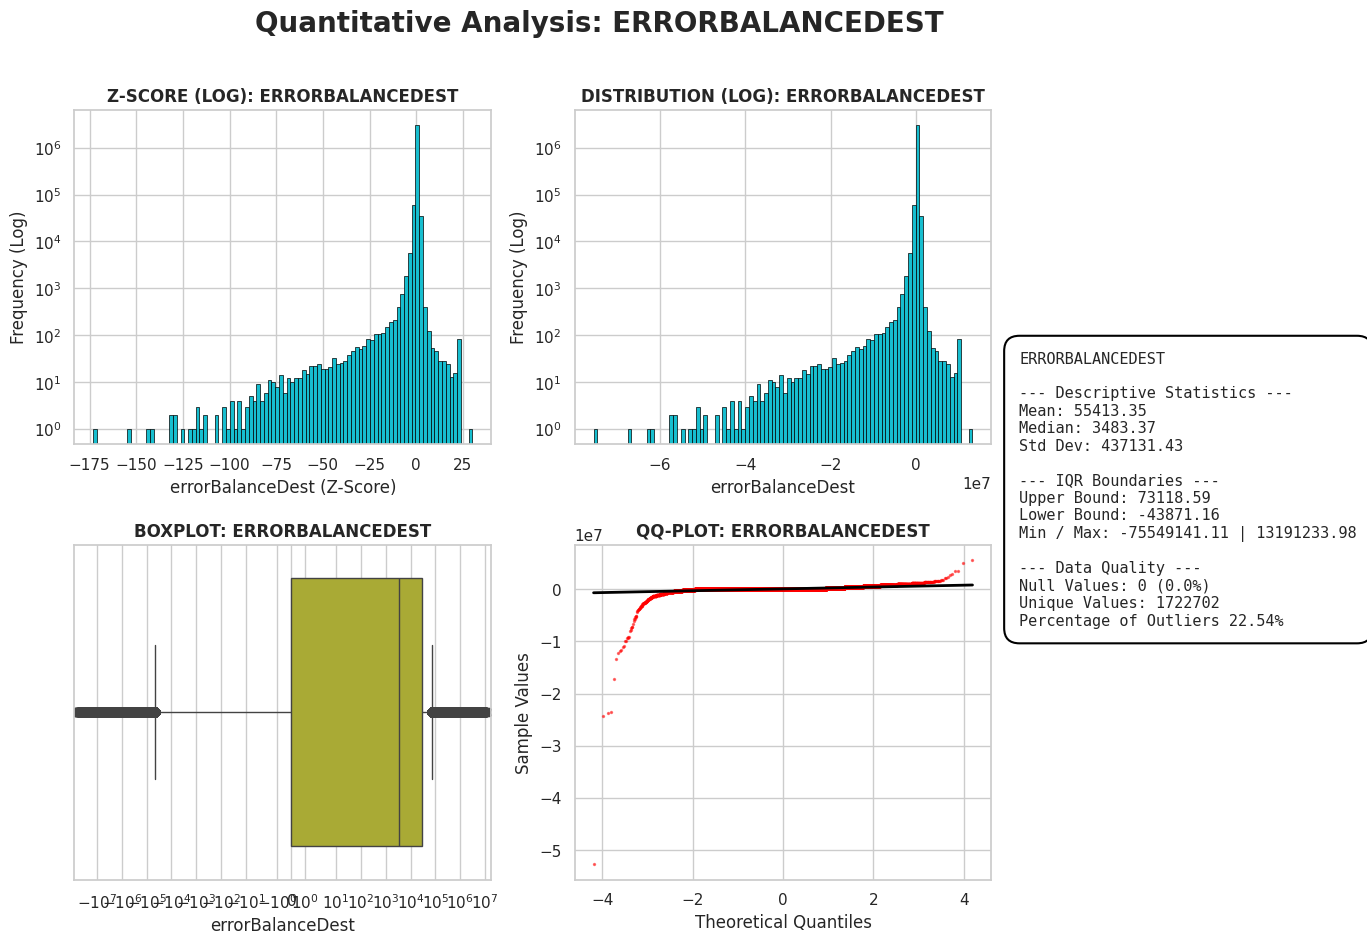

In [10]:
df_sample_pd = df.sample(fraction=0.50, seed=42).to_pandas()

# 2. Roda a função usando a amostra levinha
vis.generate_quantitative_panel(
    df=df_sample_pd,
    features=numplot_features
)

#### Insights

##### 1. Extreme Asymmetry in Financial Transactions
* The amount variable exhibits a heavily right-skewed distribution.
* The mean transfer value is **179,278.09**, but this metric is severely distorted by millionaire outliers, with the maximum value reaching a staggering **64,234,448.19**.
* **Modeling Decision:** The lack of normality, mathematically proven by the QQ-Plots forming extreme "J" curves, indicates that simple linear algorithms (like Logistic Regression) will perform poorly without prior mathematical transformations. Tree-based models (Random Forest, XGBoost) will be prioritized in the next stage, as they are robust to this asymmetry.

##### 2. The "Zeroed Account" Pattern
* The median of the newbalanceOrig variable (origin account balance after the transaction) is **exactly 0.00**.
* This means that in over half of the analyzed transactions, the sender's account was completely emptied. In the context of payment systems, this is a strong indicator of malicious behavior, suggesting Account Takeover (ATO) operations where accounts are drained to the last penny.

##### 3. Accounting Reconciliation Flaws
* The synthetic variables created (errorBalanceOrig and errorBalanceDest) revealed severe mathematical flaws within the transactional system. The final balances do not match the expected sum/subtraction of the transferred amounts.
* The errorBalanceOrig distribution concentrates a massive volume in negative numbers (reaching a minimum of **-6,423,448.19**), proving that transactions are being completed even when the account lacks sufficient funds.
* The errorBalanceDest variable signals maximum alert, containing **22.56% outliers**, with deviations ranging from -6.7 million to +13.1 million. These "mathematical breaks" are often the exact digital signature of fraudulent operations.

##### 4. Wealth Disproportion
* There is a clear financial gap in the profile of the accounts participating in these transactions:
    * **Origin Balance Median (oldbalanceOrg):** 14,231.00
    * **Destination Balance Median (oldbalanceDest):** 131,744.73
* This constant flow of money leaving smaller accounts and draining into "swollen" accounts (with peaks up to 355 million in balance) is a classic characteristic of money laundering networks. Money mules typically transfer illicit funds to larger concentrator accounts to obfuscate the financial trail.

### Categorical features distributions

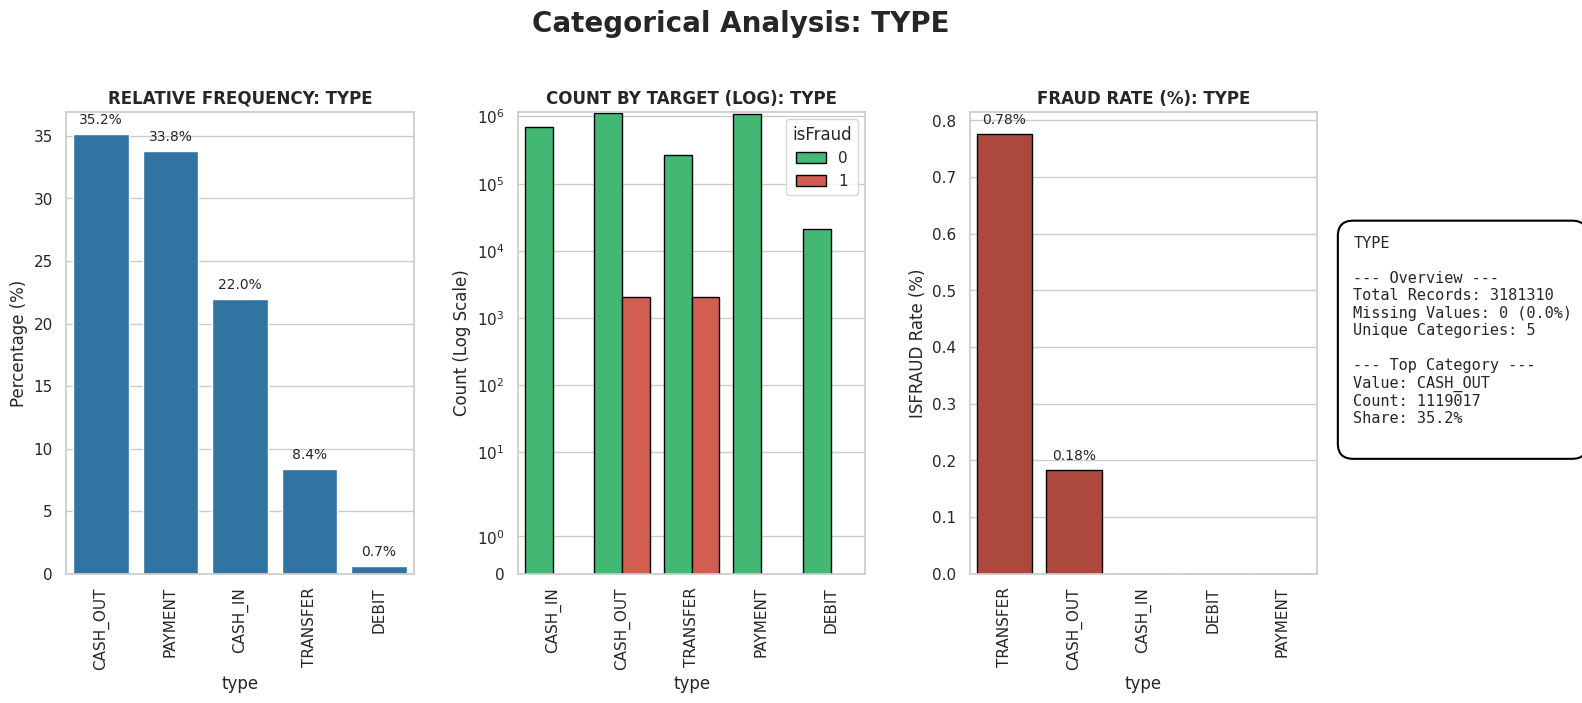

In [11]:
vis.generate_categorical_panel(
    df=df_sample_pd, 
    features=['type'], 
    target='isFraud', 
    color_map=fraud_palette
)

#### Insights
* **Exclusive Fraud Channels:** Fraud is 100% restricted to only two transaction types: TRANSFER and CASH_OUT. 
* **Highest Risk:** TRANSFER is the most dangerous operation, presenting the highest relative fraud rate (**0.78%**).
* **High Volume, Lower Rate:** CASH_OUT is the most frequent transaction in the dataset (**35.2%** of all records) and carries a fraud rate of **0.18%**.
* **Statistically Safe:** PAYMENT, CASH_IN, and DEBIT have exactly zero recorded frauds.
* **Modeling Action:** The type feature is a highly predictive variable for the Machine Learning model, as it perfectly isolates safe from risky operations.

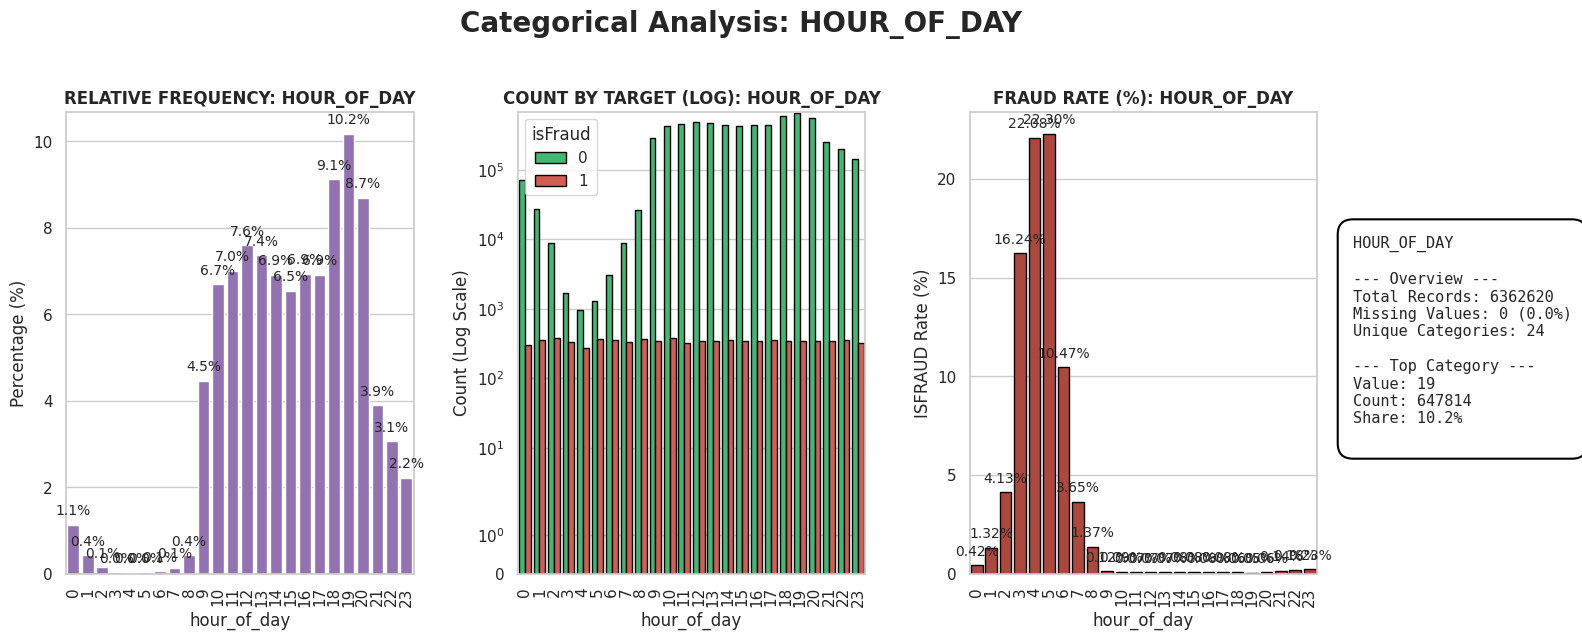

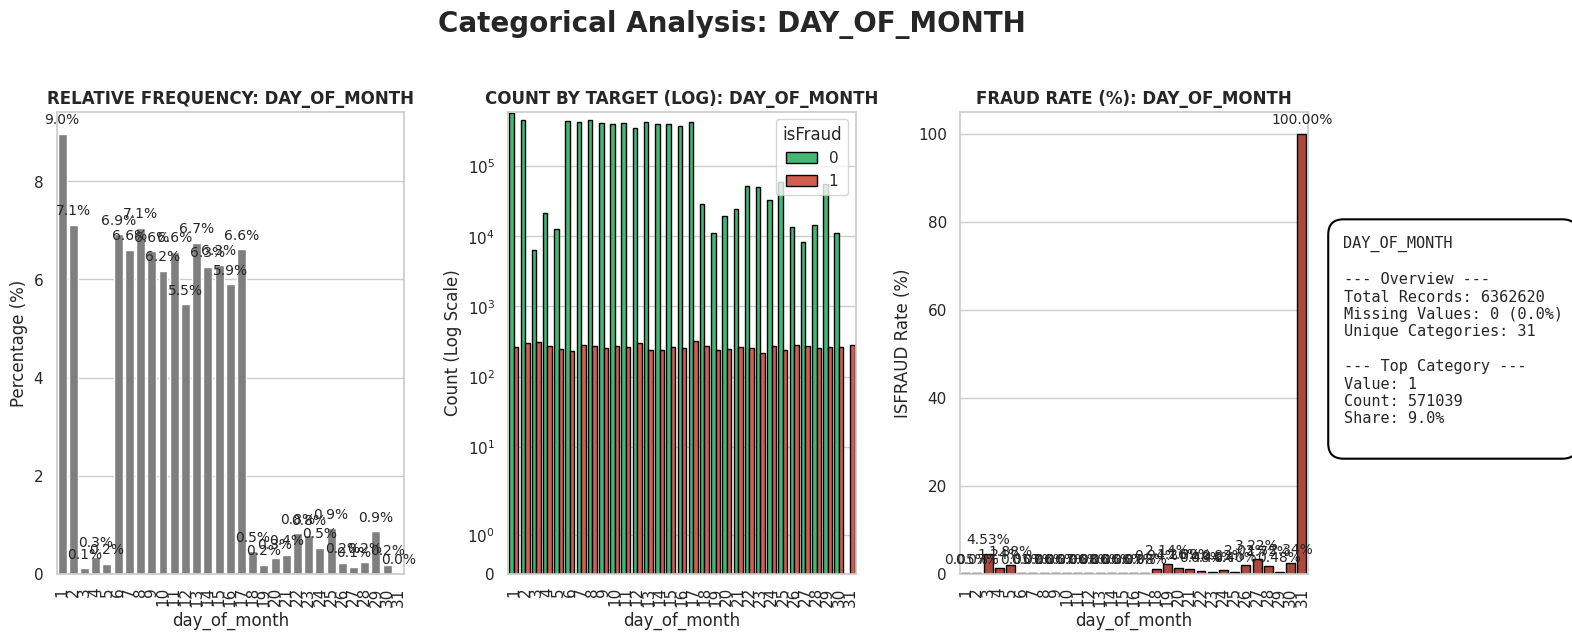

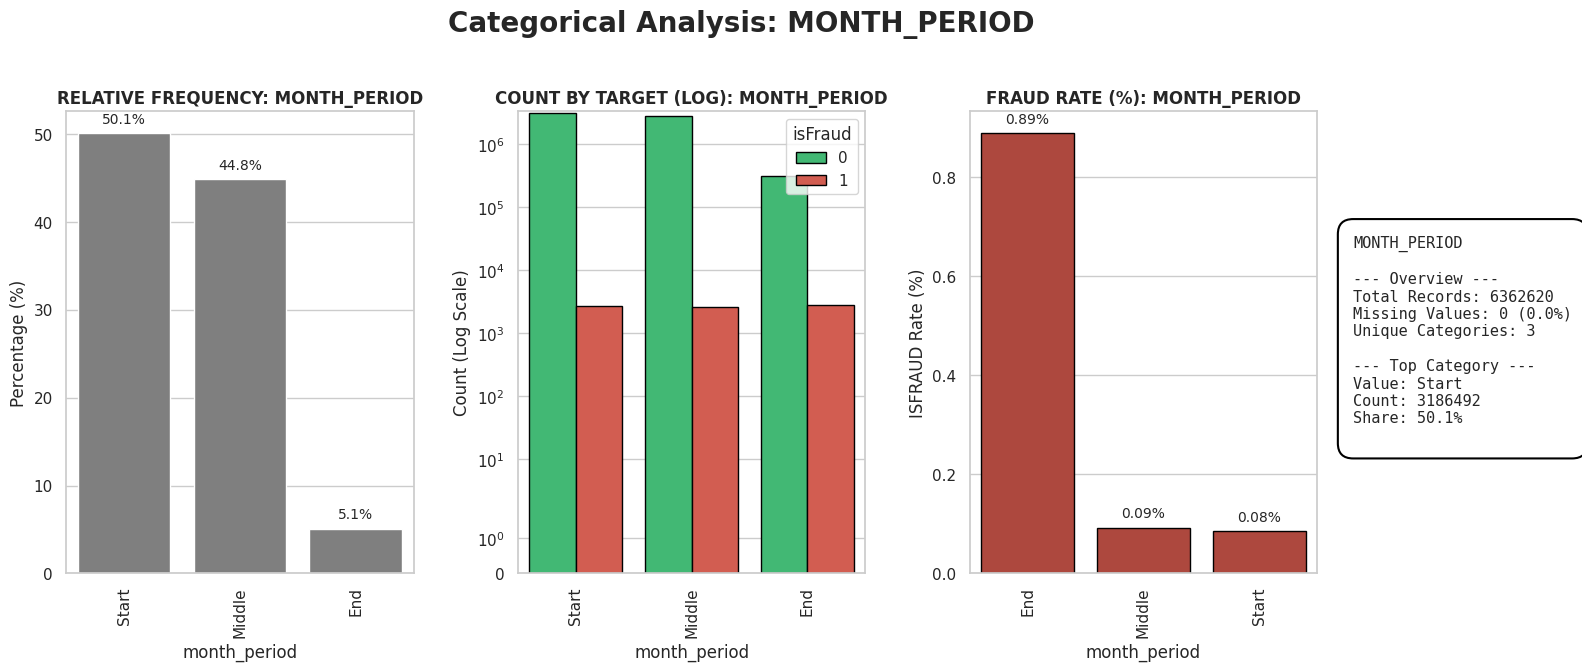

In [12]:
df = df.with_columns([
    (pl.col("step") // 24 + 1).alias("day_of_month"), # Integer division + 1 (Days 1 to 31)
    (pl.col("step") % 24).alias("hour_of_day")        # Remainder of division (Hours 0 to 23)
])

df = df.with_columns(
    pl.when(pl.col("day_of_month") <= 10).then(pl.lit("Start"))
    .when(pl.col("day_of_month") <= 20).then(pl.lit("Middle"))
    .otherwise(pl.lit("End"))
    .alias("month_period")
)



vis.generate_categorical_panel(
    df=df.to_pandas(), 
    features=['hour_of_day', 'day_of_month', 'month_period'], 
    target='isFraud', 
    color_map=fraud_palette
)



### Insights

*  Normal transaction volume follows a typical human schedule, dropping to almost zero between midnight and 6:00 AM (hours 0 to 6).
*  The absolute volume of fraud remains constant throughout the night.
*  Because legitimate transactions disappear while frauds continue, the relative *Fraud Rate* explodes to over **22%** during the early morning hours.
*  Legitimate transaction volume is highest at the beginning of the month (e.g., payday, bill payments) and steadily decreases over time.
*  On the 31st day of the month, legitimate transactions completely vanish from this dataset, but fraudulent operations continue executing.
*  The fraud rate on Day 31 hits an unbelievable **100%**. Every single transaction recorded on that specific day is a confirmed fraud.
*  Exactly half (50.1%) of all transactions occur during the "Start" of the month.
*  Fraudsters disproportionately strike at the "End" of the month when normal network volume is at its lowest (only 5.1% of total transactions).
*  The overall fraud rate is **10 times higher** at the End of the month (0.89%) compared to the Start (0.08%).
Time is a highly predictive variable in this dataset. If a transfer occurs at 4:00 AM on the 31st of the month, it carries an extreme mathematical probability of being a fraudulent attack. These engineered temporal features will be crucial for the Machine Learning model.

## Correlation Matriz

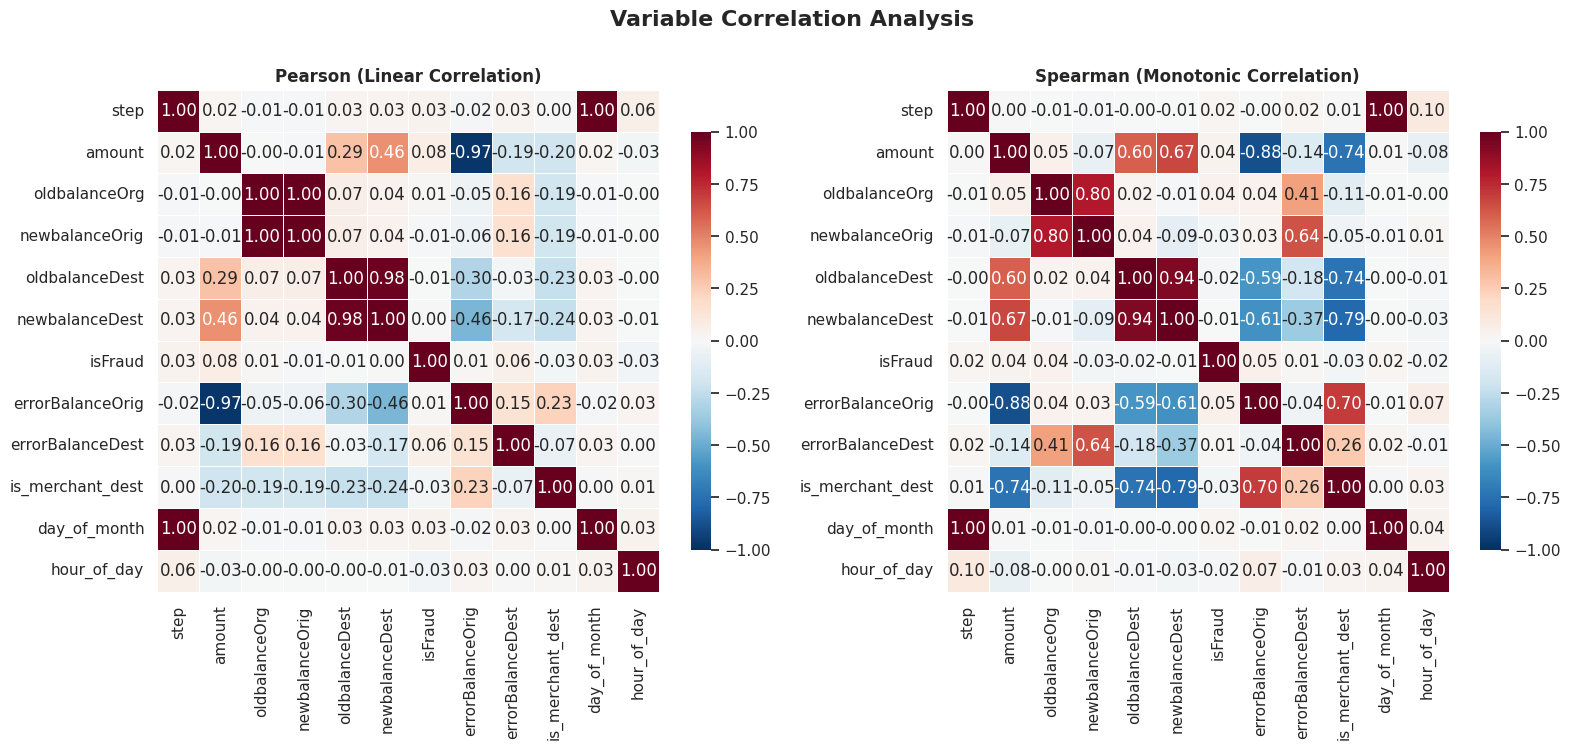

In [13]:
vis.plot_correlation_heatmaps(df.to_pandas())

#### Insights
* Spearman correlation handles non-linear and monotonic relationships effectively, bypassing massive outlier distortions present in Pearson.
* Severe multicollinearity appears among redundant time features (step,  day_of_month) and balance pairs (oldbalanceDest and newbalanceDest).
* The target variable isFraud displays near-zero individual correlation with numeric columns, confirming fraud detection requires complex feature interactions.
* Non-linear models (like Random Forest or XGBoost) are essential because simple linear relationships are non-existent.

/tmp/ipykernel_234614/1087881470.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data/PROJETOS/ALURA-FRAUDE/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


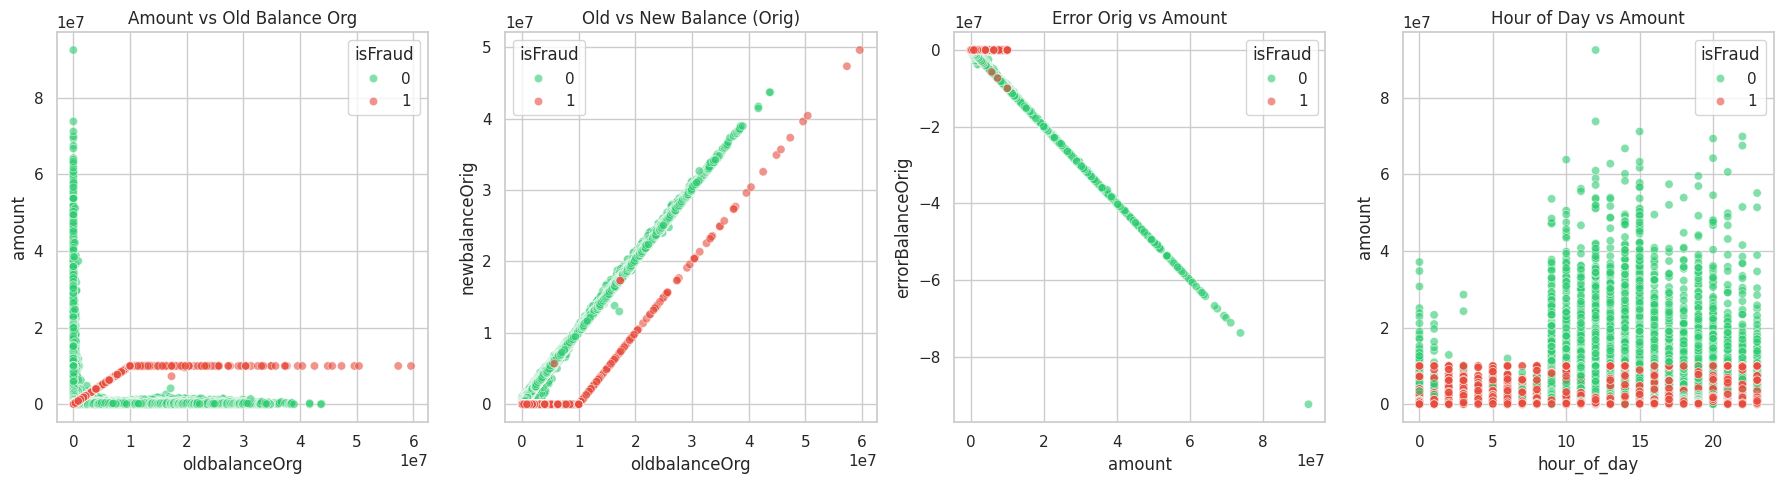

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.scatterplot(data=df, x='oldbalanceOrg', y='amount', hue='isFraud', ax=axes[0], alpha=0.6, palette={0: '#2ecc71', 1: '#e74c3c'})
axes[0].set_title('Amount vs Old Balance Org')

sns.scatterplot(data=df, x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', ax=axes[1], alpha=0.6, palette={0: '#2ecc71', 1: '#e74c3c'})
axes[1].set_title('Old vs New Balance (Orig)')

sns.scatterplot(data=df, x='amount', y='errorBalanceOrig', hue='isFraud', ax=axes[2], alpha=0.6, palette={0: '#2ecc71', 1: '#e74c3c'})
axes[2].set_title('Error Orig vs Amount')

sns.scatterplot(data=df, x='hour_of_day', y='amount', hue='isFraud', ax=axes[3], alpha=0.6, palette={0: '#2ecc71', 1: '#e74c3c'})
axes[3].set_title('Hour of Day vs Amount')

plt.tight_layout()
plt.show()

##### Insights
* **Account Draining Pattern (Old vs. New Balance):** Legitimate transactions (green) follow a predictable diagonal trend, whereas frauds (red) form a distinct cluster at the bottom where newbalanceOrig drops to zero, confirming the account-zeroing behavior.
* **Rigid Fraud Thresholds (Amount vs. Old Balance):** Fraudulent transactions (red) isolate into specific geometric lines, indicating that automated scripts execute transfers based on fixed rules or exact matching balances.
* **Strict Accounting Compliance (Error Orig vs. Amount):** Legitimate transactions adhere to a flawless, strict linear mathematical rule (the diagonal green line), proving that standard system operations follow exact accounting balances.
* **Constant Temporal Risk (Hour of Day vs. Amount):** Frauds (red) distribute uniformly across all 24 hours of the day within specific low-to-mid amount ranges, further evidencing the lack of human scheduling patterns (automated bot activity).